# Object Detection — Contour-Based Shape & Object Localization
### Detectron AI · Module 05

The live web demo uses **COCO-SSD** (a pretrained TensorFlow.js deep learning model)
for general-purpose object detection in the browser. This notebook demonstrates the
classical computer-vision approach that predates deep-learning detectors: **contour
detection + shape classification** using OpenCV — genuinely useful for industrial/robotic
vision tasks with controlled scenes (e.g. sorting parts on a conveyor belt).


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap=None):
    plt.figure(figsize=(6,4))
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()


## 1. Build a synthetic scene with known objects

(In production this would be a camera frame from a conveyor belt or webcam.)

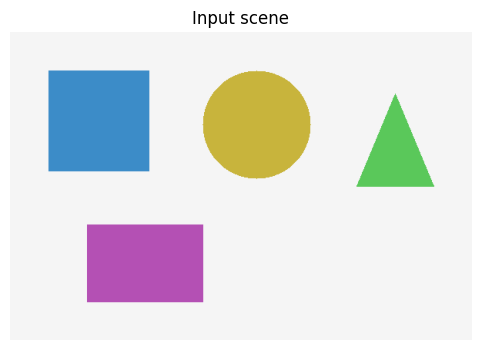

In [2]:
img = np.ones((400, 600, 3), dtype=np.uint8) * 245
cv2.rectangle(img, (50, 50), (180, 180), (200, 140, 60), -1)      # rectangle
cv2.circle(img, (320, 120), 70, (60, 180, 200), -1)                # circle
triangle = np.array([[450, 200], [550, 200], [500, 80]], np.int32)
cv2.fillPoly(img, [triangle], (90, 200, 90))                       # triangle
cv2.rectangle(img, (100, 250), (250, 350), (180, 80, 180), -1)      # square

show(img, "Input scene")


## 2. Threshold + contour detection

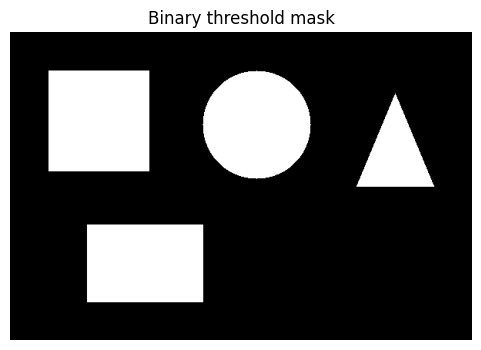

Found 4 candidate object contours


In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
show(thresh, "Binary threshold mask", cmap="gray")

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Found {len(contours)} candidate object contours")


## 3. Classify each detected object by shape

In [4]:
def classify_shape(contour):
    area = cv2.contourArea(contour)
    if area < 200:
        return None
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    vertices = len(approx)
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / float(h)

    if vertices == 3:
        label = "triangle"
    elif vertices == 4:
        label = "square" if 0.9 <= aspect_ratio <= 1.1 else "rectangle"
    elif vertices > 6:
        label = "circle"
    else:
        label = f"polygon-{vertices}"
    return {"label": label, "area": area, "bbox": (x, y, w, h), "vertices": vertices}

detections = [classify_shape(c) for c in contours]
detections = [d for d in detections if d is not None]
for d in detections:
    print(d)


{'label': 'rectangle', 'area': 15000.0, 'bbox': (100, 250, 151, 101), 'vertices': 4}
{'label': 'triangle', 'area': 6000.0, 'bbox': (450, 80, 101, 121), 'vertices': 3}
{'label': 'circle', 'area': 15176.0, 'bbox': (250, 50, 141, 141), 'vertices': 8}
{'label': 'square', 'area': 16900.0, 'bbox': (50, 50, 131, 131), 'vertices': 4}


## 4. Draw bounding boxes and labels (mirrors the live web demo's overlay style)

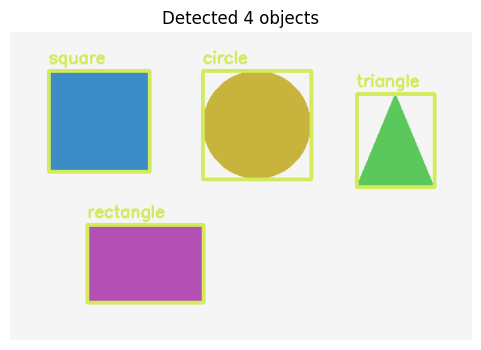

In [5]:
output = img.copy()
for d in detections:
    x, y, w, h = d["bbox"]
    cv2.rectangle(output, (x, y), (x+w, y+h), (94, 234, 212), 3)
    cv2.putText(output, d["label"], (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (94, 234, 212), 2)

show(output, f"Detected {len(detections)} objects")


## Notes

- This pipeline (grayscale → threshold → `findContours` → `approxPolyDP` shape
  classification) is the standard classical-CV approach for object detection in
  controlled environments — fast, fully deterministic, and requires no training data.
- The live web demo instead uses **COCO-SSD**, a deep convolutional network pretrained
  on 80 real-world object classes (person, car, dog, etc.), which generalizes far better
  to unconstrained photos but needs a trained model rather than hand-tuned thresholds.
- For production part-inspection systems, this contour-based approach is still widely
  used because it's fast, explainable, and doesn't require GPU inference.
